In [6]:
# Load modules

## https://github.com/rishavgoyal55/NEW-ZONAL-WAVE-3-INDEX/blob/main/ZW3index_calculation_Goyaletal2022_v2.ipynb ##

import numpy as np
import scipy as sc
import xarray as xr
import matplotlib.pyplot as plt
from eofs.standard import Eof
import cartopy.crs as ccrs
import cartopy.crs as ccrs
import cartopy
import matplotlib as mpl
import scipy as sc
import cartopy.feature
import matplotlib.path as mpath
from cartopy.util import add_cyclic_point as cycpt
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.ticker as mticker

In [14]:
path = '/Users/iw2g24/PycharmProjects/SSH_project/'
ds_era5 = xr.open_dataset(path + 'Data/ERA5_2000_2025.nc')

In [15]:
print(ds_era5)

<xarray.Dataset> Size: 564MB
Dimensions:         (valid_time: 304, pressure_level: 1, latitude: 161,
                     longitude: 1440)
Coordinates:
    number          int64 8B ...
  * valid_time      (valid_time) datetime64[ns] 2kB 2000-01-01 ... 2025-04-01
  * pressure_level  (pressure_level) float64 8B 500.0
  * latitude        (latitude) float64 1kB -50.0 -50.25 -50.5 ... -89.75 -90.0
  * longitude       (longitude) float64 12kB -180.0 -179.8 ... 179.5 179.8
    expver          (valid_time) <U4 5kB ...
Data variables:
    u               (valid_time, pressure_level, latitude, longitude) float32 282MB ...
    v               (valid_time, pressure_level, latitude, longitude) float32 282MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts


In [20]:

# Subsample data to only consider meridional winds at 500 hPa and from 40S - 70S and then calculate monthly anomalies

v = ds_era5.v.sel(pressure_level=500, valid_time=slice('2000','2023')).sel(latitude=slice(-40,-70)).groupby('valid_time.month') - ds.v.sel(pressure_level=500, valid_time=slice('2000','2023')).sel(latitude=slice(-40,-70)).groupby('valid_time.month').mean(dim='valid_time')

In [21]:
# Carry out the EOFs

lat    = v.latitude
coslat = np.cos(np.deg2rad(lat.values)).clip(0.,1.)
wgts   = np.sqrt(coslat)[...,np.newaxis]
solver = Eof(v.values, weights=wgts)
eof    = solver.eofsAsCovariance(neofs=6)
pcs    = solver.pcs(npcs=6, pcscaling=1)
var    = solver.varianceFraction()

In [25]:
# Calculate the ZW3 magnitude and phase indices

zw3magnitude_index = (pcs[:,0]**2 + pcs[:,1]**2)**0.5

zw3phase_index = np.zeros(len(v[:,0,0]))

for i in range(len(v[:,0,0])):
    if((pcs[i,0]>0) and (pcs[i,1]>0)):
        zw3phase_index[i] = np.arctan(pcs[i,1] / pcs[i,0]) * 180 / (np.pi)
    elif((pcs[i,0]<0) and (pcs[i,1]>0)):
        zw3phase_index[i] = (np.arctan(pcs[i,1] / pcs[i,0]) * 180 / (np.pi)) + 180
    elif((pcs[i,0]>0) and (pcs[i,1]<0)):
        zw3phase_index[i] = (np.arctan(pcs[i,1] / pcs[i,0]) * 180 / (np.pi))
    elif((pcs[i,0]<0) and (pcs[i,1]<0)):
        zw3phase_index[i] = (np.arctan(pcs[i,1] / pcs[i,0]) * 180 / (np.pi)) - 180

In [27]:
magnitude_index = xr.DataArray(zw3magnitude_index, coords=[v.valid_time], name='zw3index_magnitude')
phase_index     = xr.DataArray(zw3phase_index, coords=[v.valid_time], name='zw3index_phase')
pc1             = xr.DataArray(pcs[:,0], coords=[v.valid_time], name='pc1')
pc2             = xr.DataArray(pcs[:,1], coords=[v.valid_time], name='pc2')

In [28]:
# Combine all DataArrays into a single Dataset
zw3_dataset = xr.Dataset({
    'zw3index_magnitude': magnitude_index,
    'zw3index_phase': phase_index,
    'pc1': pc1,
    'pc2': pc2
})

In [29]:
zw3_dataset.to_netcdf('/Users/iw2g24/PycharmProjects/SSH_project/mca_shared_izzy/zw3_ds.nc')

In [30]:
path = '/Users/iw2g24/PycharmProjects/SSH_project/mca_shared_izzy/'
ds_zw3 = xr.open_dataset(path + 'zw3_ds.nc')

In [49]:
print(ds_zw3['valid_time'].values)

['2000-01-01T00:00:00.000000000' '2000-02-01T00:00:00.000000000'
 '2000-03-01T00:00:00.000000000' '2000-04-01T00:00:00.000000000'
 '2000-05-01T00:00:00.000000000' '2000-06-01T00:00:00.000000000'
 '2000-07-01T00:00:00.000000000' '2000-08-01T00:00:00.000000000'
 '2000-09-01T00:00:00.000000000' '2000-10-01T00:00:00.000000000'
 '2000-11-01T00:00:00.000000000' '2000-12-01T00:00:00.000000000'
 '2001-01-01T00:00:00.000000000' '2001-02-01T00:00:00.000000000'
 '2001-03-01T00:00:00.000000000' '2001-04-01T00:00:00.000000000'
 '2001-05-01T00:00:00.000000000' '2001-06-01T00:00:00.000000000'
 '2001-07-01T00:00:00.000000000' '2001-08-01T00:00:00.000000000'
 '2001-09-01T00:00:00.000000000' '2001-10-01T00:00:00.000000000'
 '2001-11-01T00:00:00.000000000' '2001-12-01T00:00:00.000000000'
 '2002-01-01T00:00:00.000000000' '2002-02-01T00:00:00.000000000'
 '2002-03-01T00:00:00.000000000' '2002-04-01T00:00:00.000000000'
 '2002-05-01T00:00:00.000000000' '2002-06-01T00:00:00.000000000'
 '2002-07-01T00:00:00.000

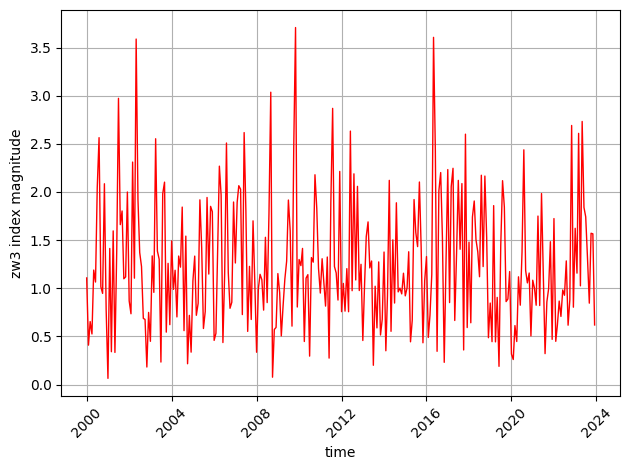

In [58]:
plt.plot(ds_zw3['valid_time'], ds_zw3['zw3index_magnitude'], linewidth=1, color='r')
plt.xlabel('time')
plt.ylabel('zw3 index magnitude')
plt.grid('True')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [53]:
smoothed_zw3_idx = ds_zw3['zw3index_magnitude'].rolling(valid_time=6, center=True).mean()

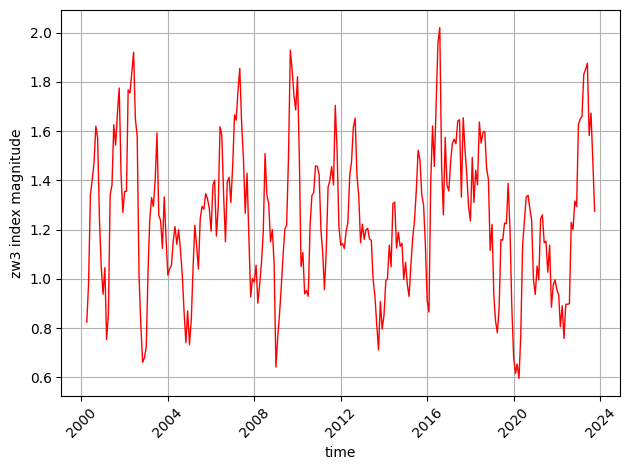

In [59]:
plt.plot(ds_zw3['valid_time'], smoothed_zw3_idx,linewidth=1, color='r')
plt.xlabel('time')
plt.ylabel('zw3 index magnitude')
plt.grid('True')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [55]:
path = '/Users/iw2g24/PycharmProjects/SSH_project/mca_shared_izzy/'
ds_monthly_SOI = xr.open_dataset(path + 'monthly_SOI.nc')

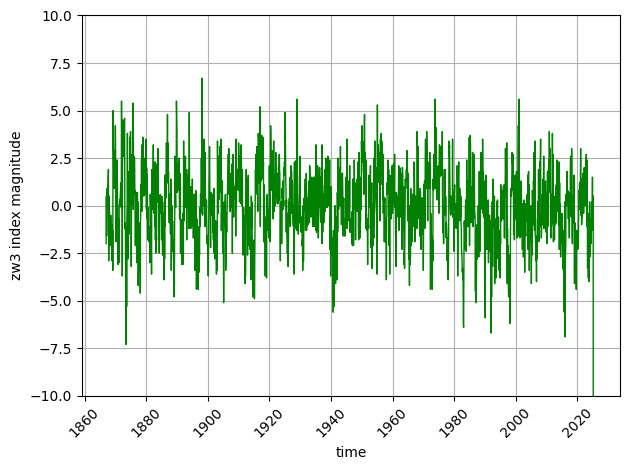

In [64]:
plt.plot(ds_monthly_SOI['time'], ds_monthly_SOI['SOI'],linewidth=1, color='g')
plt.xlabel('time')
plt.ylabel('zw3 index magnitude')
plt.ylim(-10,10)
plt.grid('True')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [65]:
path = '/Users/iw2g24/PycharmProjects/SSH_project/mca_shared_izzy/'
ds_monthly_SOI_masked = xr.open_dataset(path + 'soi_sam_masked.nc')

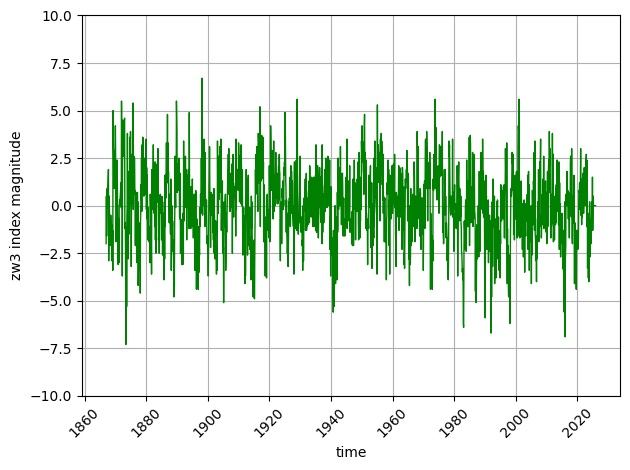

In [66]:
plt.plot(ds_monthly_SOI_masked['time'], ds_monthly_SOI_masked['SOI'],linewidth=1, color='g')
plt.xlabel('time')
plt.ylabel('zw3 index magnitude')
plt.ylim(-10,10)
plt.grid('True')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [68]:
smoothed_soi = ds_monthly_SOI_masked['SOI'].rolling(time=6, center=True).mean()

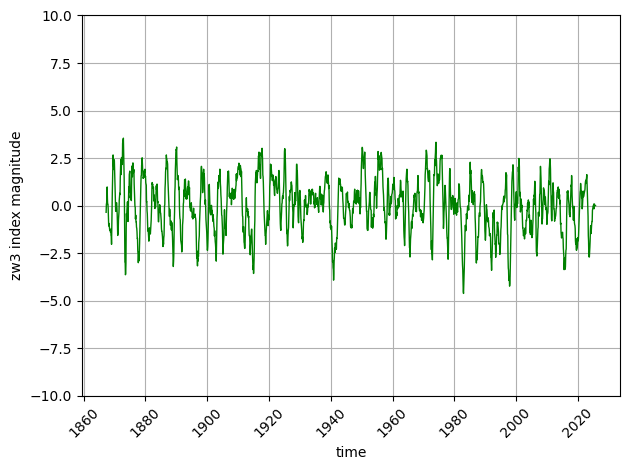

In [69]:
plt.plot(ds_monthly_SOI_masked['time'], smoothed_soi,linewidth=1, color='g')
plt.xlabel('time')
plt.ylabel('zw3 index magnitude')
plt.ylim(-10,10)
plt.grid('True')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()